# How 2×2 Matrix Elements Work

## Purpose

Understand what each entry of a 2×2 matrix contributes to a transformation.

The previous notebook introduced matrix-vector multiplication as:

$$
A\mathbf{v}
$$

In Python, we calculate this as:

```python
A @ v
```

This notebook looks inside a 2×2 matrix and asks:

> what does each individual entry actually do?

This is a short aside before looking at named transformations such as scaling, reflection, and shear.

## Setup

We will use the standard basis vectors:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

and a simple example vector:

$$
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

The basis vectors show what the matrix does to the x-direction and y-direction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


e1 = np.array([1, 0])
e2 = np.array([0, 1])
v = np.array([2, 1])


def setup_axis(ax, title, xlim=(-1.25, 3.25), ylim=(-1.25, 3.25)):
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_vector(
    ax,
    vector,
    origin=(0, 0),
    label=None,
    label_offset=(0.08, 0.08),
    linewidth=2,
    alpha=1.0,
    linestyle="-",
):
    origin = np.array(origin, dtype=float)
    vector = np.array(vector, dtype=float)

    ax.arrow(
        origin[0],
        origin[1],
        vector[0],
        vector[1],
        length_includes_head=True,
        head_width=0.07,
        head_length=0.11,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
    )

    if label is not None:
        end = origin + vector
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=11,
        )


def print_vector(name, vector):
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")


def print_results_for_entry(entry_name, values, build_matrix):
    print(f"{entry_name:>5}    Av")
    print("-" * 24)
    for value in values:
        A = build_matrix(value)
        Av = A @ v
        print(f"{value:>5.1f}    [{Av[0]:>5.2f}, {Av[1]:>5.2f}]")


def plot_basis_effect(A, title, xlim=(-1.25, 3.25), ylim=(-1.25, 3.25)):
    Ae1 = A @ e1
    Ae2 = A @ e2
    Av = A @ v

    fig, ax = plt.subplots(figsize=(5, 4))
    setup_axis(ax, title, xlim=xlim, ylim=ylim)

    # Faint original references.
    draw_vector(ax, e1, label="$e_1$", label_offset=(0.04, -0.22), alpha=0.35, linewidth=1.5)
    draw_vector(ax, e2, label="$e_2$", label_offset=(-0.25, 0.05), alpha=0.35, linewidth=1.5)
    draw_vector(ax, v, label="$v$", label_offset=(0.08, 0.08), alpha=0.35, linewidth=1.5)

    # Transformed basis vectors and transformed example vector.
    draw_vector(ax, Ae1, label="$Ae_1$", label_offset=(0.06, 0.08), linewidth=2.2)
    draw_vector(ax, Ae2, label="$Ae_2$", label_offset=(0.08, 0.06), linewidth=2.2)
    draw_vector(ax, Av, label="$Av$", label_offset=(0.08, 0.08), linewidth=2.5)

    plt.show()


def plot_basis_only(A, title, xlim=(-1.25, 3.25), ylim=(-1.25, 3.25)):
    Ae1 = A @ e1
    Ae2 = A @ e2

    fig, ax = plt.subplots(figsize=(5, 4))
    setup_axis(ax, title, xlim=xlim, ylim=ylim)

    # Faint original basis vectors for comparison.
    draw_vector(ax, e1, label="$e_1$", label_offset=(0.04, -0.22), alpha=0.35, linewidth=1.5)
    draw_vector(ax, e2, label="$e_2$", label_offset=(-0.25, 0.05), alpha=0.35, linewidth=1.5)

    # Main focus: transformed basis vectors.
    draw_vector(ax, Ae1, label="$Ae_1$", label_offset=(0.06, 0.08), linewidth=2.4)
    draw_vector(ax, Ae2, label="$Ae_2$", label_offset=(0.08, 0.06), linewidth=2.4)

    plt.show()

## The general 2×2 matrix

A general 2×2 matrix can be written as:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

For a vector:

$$
\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

matrix-vector multiplication gives:

$$
A\mathbf{v}
=
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
ax + by \\
cx + dy
\end{bmatrix}
$$

This is the **row view**:

- $a$: input x contributes to output x
- $b$: input y contributes to output x
- $c$: input x contributes to output y
- $d$: input y contributes to output y

## The same matrix as transformed basis vectors

The **column view** is often better for visualising transformations.

For:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

the first column is where $\mathbf{e}_1$ lands:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
a \\
c
\end{bmatrix}
$$

and the second column is where $\mathbf{e}_2$ lands:

$$
A\mathbf{e}_2 =
\begin{bmatrix}
b \\
d
\end{bmatrix}
$$

So each entry has two useful readings:

- the row view tells us how output coordinates are calculated
- the column view tells us how the basis vectors move

In [2]:
A = np.array([
    [2, 1],
    [1, 3],
])

print("A:")
print(A)
print()
print_vector("first column", A[:, 0])
print_vector("A e1", A @ e1)
print()
print_vector("second column", A[:, 1])
print_vector("A e2", A @ e2)

A:
[[2 1]
 [1 3]]

first column = [ 2.00,  1.00]
A e1 = [ 2.00,  1.00]

second column = [ 1.00,  3.00]
A e2 = [ 1.00,  3.00]


The columns are not just stored numbers.

They are the destinations of the basis vectors.

## The zero matrix: everything collapses

Start with the zero matrix:

$$
A =
\begin{bmatrix}
0 & 0 \\
0 & 0
\end{bmatrix}
$$

This sends both basis vectors to the origin:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
0 \\
0
\end{bmatrix}
\qquad
A\mathbf{e}_2 =
\begin{bmatrix}
0 \\
0
\end{bmatrix}
$$

So every vector collapses to the origin.

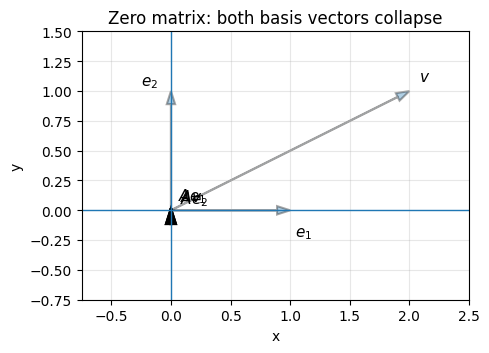

In [3]:
A = np.array([
    [0, 0],
    [0, 0],
])

plot_basis_effect(
    A,
    title="Zero matrix: both basis vectors collapse",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 1.5),
)

## Building towards the identity matrix

The identity matrix is:

$$
I =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

It leaves vectors unchanged.

Before jumping straight to the identity matrix, build it from the diagonal entries.

## Top-left entry: x contributes to output x

First set only the top-left entry to 1:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & 0
\end{bmatrix}
$$

For:

$$
\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

this gives:

$$
A\mathbf{v} =
\begin{bmatrix}
x \\
0
\end{bmatrix}
$$

The input x-coordinate survives. The input y-coordinate is discarded.

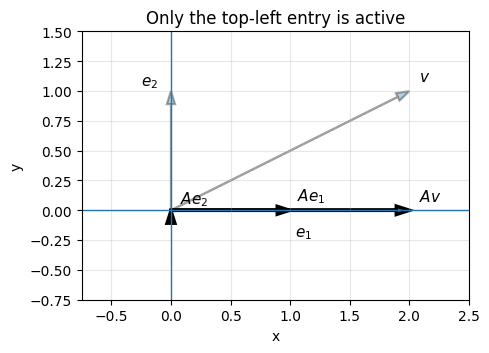

In [4]:
A = np.array([
    [1, 0],
    [0, 0],
])

plot_basis_effect(
    A,
    title="Only the top-left entry is active",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 1.5),
)

Geometrically, $\mathbf{e}_1$ stays where it is, while $\mathbf{e}_2$ collapses to zero.

This flattens everything onto the x-axis.

## Bottom-right entry: y contributes to output y

Now set only the bottom-right entry to 1:

$$
A =
\begin{bmatrix}
0 & 0 \\
0 & 1
\end{bmatrix}
$$

This gives:

$$
A\mathbf{v} =
\begin{bmatrix}
0 \\
y
\end{bmatrix}
$$

The input y-coordinate survives. The input x-coordinate is discarded.

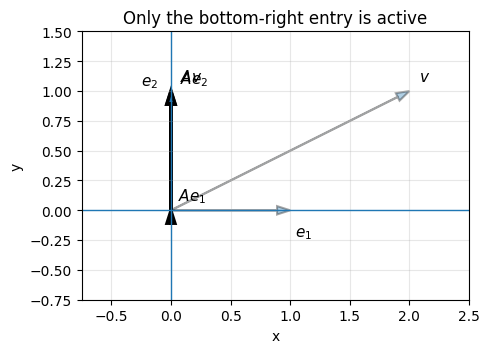

In [5]:
A = np.array([
    [0, 0],
    [0, 1],
])

plot_basis_effect(
    A,
    title="Only the bottom-right entry is active",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 1.5),
)

Geometrically, $\mathbf{e}_2$ stays where it is, while $\mathbf{e}_1$ collapses to zero.

This flattens everything onto the y-axis.

## The identity matrix: nothing changes

Combine the two diagonal entries:

$$
I =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

This gives:

$$
I\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

The x-coordinate contributes to output x. The y-coordinate contributes to output y. There is no mixing between x and y.

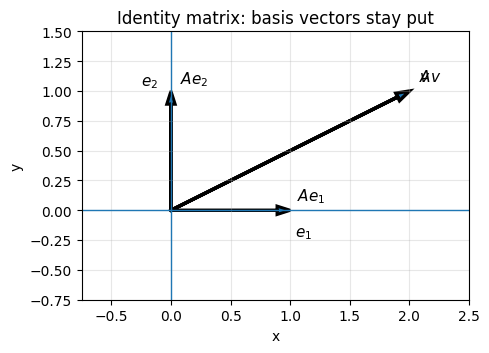

In [6]:
I = np.array([
    [1, 0],
    [0, 1],
])

plot_basis_effect(
    I,
    title="Identity matrix: basis vectors stay put",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 1.5),
)

The identity matrix is the “do nothing” transformation.

Other transformations can be understood as changes away from this baseline.

## Diagonal entries: scaling and flipping directions

The diagonal entries are $a$ and $d$:

$$
A =
\begin{bmatrix}
a & 0 \\
0 & d
\end{bmatrix}
$$

They preserve the x/y directions, but can scale, collapse, or flip them.

The off-diagonal entries come later because they mix one coordinate into the other.

## Varying the top-left entry $a$

Now vary the top-left entry:

$$
A =
\begin{bmatrix}
a & 0 \\
0 & 1
\end{bmatrix}
$$

This controls how much input x contributes to output x.

In column terms, it changes where $\mathbf{e}_1$ lands:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
a \\
0
\end{bmatrix}
$$

In [7]:
print_results_for_entry(
    "a",
    [0.5, 1, 2, -1],
    lambda a: np.array([
        [a, 0],
        [0, 1],
    ]),
)

    a    Av
------------------------
  0.5    [ 1.00,  1.00]
  1.0    [ 2.00,  1.00]
  2.0    [ 4.00,  1.00]
 -1.0    [-2.00,  1.00]


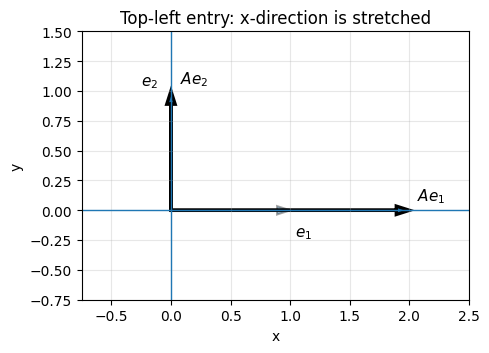

In [8]:
A = np.array([
    [2, 0],
    [0, 1],
])

plot_basis_only(
    A,
    title="Top-left entry: x-direction is stretched",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 1.5),
)

Increasing $a$ stretches the x-direction.

Making $a$ negative flips the x-direction.

Making $a$ zero collapses the x-direction.

## Varying the bottom-right entry $d$

Now vary the bottom-right entry:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & d
\end{bmatrix}
$$

This controls how much input y contributes to output y.

In column terms, it changes where $\mathbf{e}_2$ lands:

$$
A\mathbf{e}_2 =
\begin{bmatrix}
0 \\
d
\end{bmatrix}
$$

In [9]:
print_results_for_entry(
    "d",
    [0.5, 1, 2, -1],
    lambda d: np.array([
        [1, 0],
        [0, d],
    ]),
)

    d    Av
------------------------
  0.5    [ 2.00,  0.50]
  1.0    [ 2.00,  1.00]
  2.0    [ 2.00,  2.00]
 -1.0    [ 2.00, -1.00]


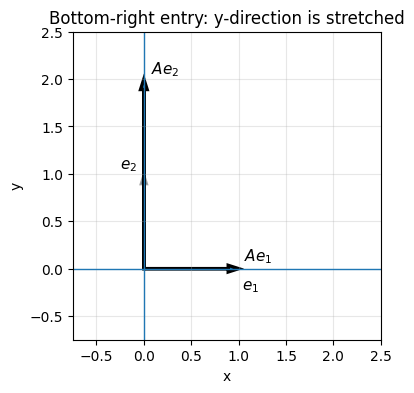

In [10]:
A = np.array([
    [1, 0],
    [0, 2],
])

plot_basis_only(
    A,
    title="Bottom-right entry: y-direction is stretched",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 2.5),
)

Increasing $d$ stretches the y-direction.

Making $d$ negative flips the y-direction.

Making $d$ zero collapses the y-direction.

## Off-diagonal entries: mixing coordinates

The off-diagonal entries are $b$ and $c$:

$$
A =
\begin{bmatrix}
1 & b \\
c & 1
\end{bmatrix}
$$

They mix coordinates:

- $b$ lets input y contribute to output x
- $c$ lets input x contribute to output y

This is where shear-like behaviour comes from.

## Varying the top-right entry $b$

Now vary the top-right entry:

$$
A =
\begin{bmatrix}
1 & b \\
0 & 1
\end{bmatrix}
$$

This controls how much input y contributes to output x.

For:

$$
\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

we get:

$$
A\mathbf{v} =
\begin{bmatrix}
x + by \\
y
\end{bmatrix}
$$

In column terms, $b$ changes the x-coordinate of $A\mathbf{e}_2$:

$$
A\mathbf{e}_2 =
\begin{bmatrix}
b \\
1
\end{bmatrix}
$$

In [11]:
print_results_for_entry(
    "b",
    [-1, 0, 1, 2],
    lambda b: np.array([
        [1, b],
        [0, 1],
    ]),
)

    b    Av
------------------------
 -1.0    [ 1.00,  1.00]
  0.0    [ 2.00,  1.00]
  1.0    [ 3.00,  1.00]
  2.0    [ 4.00,  1.00]


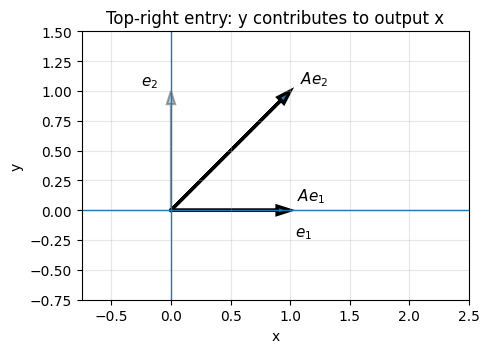

In [12]:
A = np.array([
    [1, 1],
    [0, 1],
])

plot_basis_only(
    A,
    title="Top-right entry: y contributes to output x",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 1.5),
)

This produces a horizontal shear.

The y-coordinate stays the same, but points higher up are pushed sideways more.

## Varying the bottom-left entry $c$

Now vary the bottom-left entry:

$$
A =
\begin{bmatrix}
1 & 0 \\
c & 1
\end{bmatrix}
$$

This controls how much input x contributes to output y.

For:

$$
\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

we get:

$$
A\mathbf{v} =
\begin{bmatrix}
x \\
cx + y
\end{bmatrix}
$$

In column terms, $c$ changes the y-coordinate of $A\mathbf{e}_1$:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
1 \\
c
\end{bmatrix}
$$

In [13]:
print_results_for_entry(
    "c",
    [-1, 0, 1, 2],
    lambda c: np.array([
        [1, 0],
        [c, 1],
    ]),
)

    c    Av
------------------------
 -1.0    [ 2.00, -1.00]
  0.0    [ 2.00,  1.00]
  1.0    [ 2.00,  3.00]
  2.0    [ 2.00,  5.00]


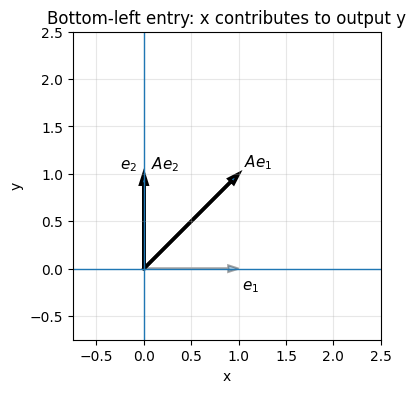

In [14]:
A = np.array([
    [1, 0],
    [1, 1],
])

plot_basis_only(
    A,
    title="Bottom-left entry: x contributes to output y",
    xlim=(-0.75, 2.5),
    ylim=(-0.75, 2.5),
)

This produces a vertical shear.

The x-coordinate stays the same, but points farther to the right are pushed upward more.

## Summary

For a 2×2 matrix:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

and a vector:

$$
\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

the row view is:

$$
A\mathbf{v} =
\begin{bmatrix}
ax + by \\
cx + dy
\end{bmatrix}
$$

The column view is:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
a \\
c
\end{bmatrix}
\qquad
A\mathbf{e}_2 =
\begin{bmatrix}
b \\
d
\end{bmatrix}
$$

| Entry | Row view | Column / basis-vector view | Common effect |
|---|---|---|---|
| $a$ | input x contributes to output x | changes the x-coordinate of $A\mathbf{e}_1$ | x scaling, x reflection, or x collapse |
| $b$ | input y contributes to output x | changes the x-coordinate of $A\mathbf{e}_2$ | horizontal shear / mixing |
| $c$ | input x contributes to output y | changes the y-coordinate of $A\mathbf{e}_1$ | vertical shear / mixing |
| $d$ | input y contributes to output y | changes the y-coordinate of $A\mathbf{e}_2$ | y scaling, y reflection, or y collapse |

The central idea is:

> the rows explain the arithmetic, but the columns explain where the basis vectors go.

## Next step

Next, look at named transformations such as scaling, reflection, and shear.

Those transformations are built from the same four matrix entries.